In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df=pd.read_csv('Teen_Mental_Health_Dataset.csv')
df=df.dropna()
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [3]:
x=df.drop('depression_label',axis=1)
y=df['depression_label']
x=pd.get_dummies(x)
test=[0.05,0.1,0.15,0.2,0.25]
d={'model':[],'acc':[],'test_size':[]}
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    
    knn=KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,knn.predict(x_test)))
    d['model'].append('Knn')
    d['test_size'].append(i)

    dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
    dt.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,dt.predict(x_test)))
    d['model'].append('DT')
    d['test_size'].append(i)    

    rf=RandomForestClassifier(criterion='entropy',max_depth=4,n_estimators=100,random_state=42)
    rf.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,rf.predict(x_test)))
    d['model'].append('RF')
    d['test_size'].append(i) 

    svm=SVC(C=1,random_state=42,kernel='rbf')
    svm.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,svm.predict(x_test)))
    d['model'].append('SVC')
    d['test_size'].append(i)

print(d)
df1=pd.DataFrame(d)
df1

{'model': ['Knn', 'DT', 'RF', 'SVC', 'Knn', 'DT', 'RF', 'SVC', 'Knn', 'DT', 'RF', 'SVC', 'Knn', 'DT', 'RF', 'SVC', 'Knn', 'DT', 'RF', 'SVC'], 'acc': [0.9333333333333333, 1.0, 0.9333333333333333, 0.9333333333333333, 0.9583333333333334, 1.0, 0.9583333333333334, 0.9583333333333334, 0.9722222222222222, 1.0, 0.9722222222222222, 0.9722222222222222, 0.975, 1.0, 0.975, 0.975, 0.9733333333333334, 0.9966666666666667, 0.9733333333333334, 0.9733333333333334], 'test_size': [0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.15, 0.15, 0.15, 0.15, 0.2, 0.2, 0.2, 0.2, 0.25, 0.25, 0.25, 0.25]}


,model,acc,test_size
0,Knn,0.933333,0.05
1,DT,1.000000,0.05
2,RF,0.933333,0.05
3,SVC,0.933333,0.05
4,Knn,0.958333,0.10
5,DT,1.000000,0.10
6,RF,0.958333,0.10
7,SVC,0.958333,0.10
8,Knn,0.972222,0.15
9,DT,1.000000,0.15


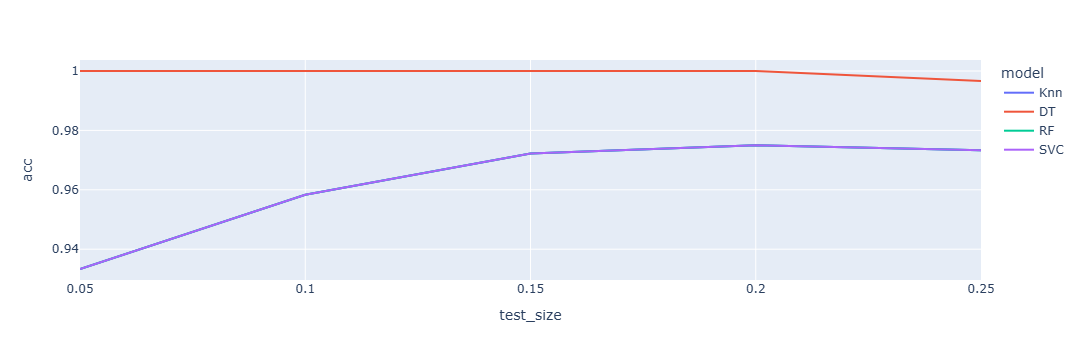

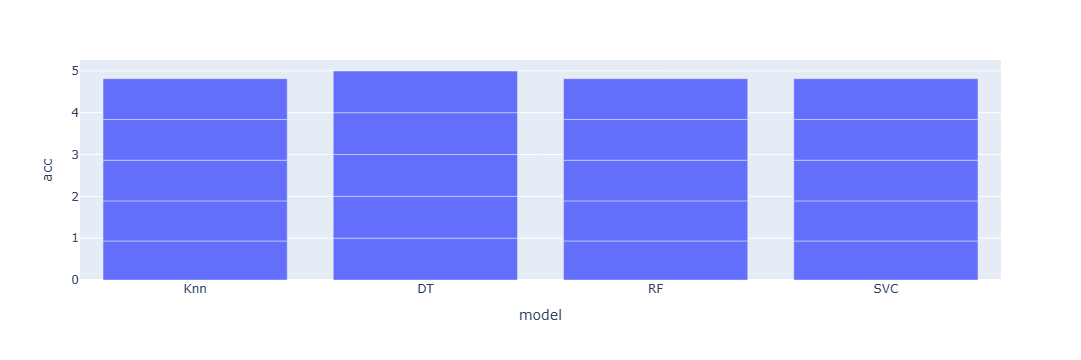

In [4]:
fig=px.line(data_frame=df1,x='test_size',y='acc',color='model')
fig.show()

fig=px.bar(data_frame=df1,x='model',y='acc')
fig.show()

In [5]:
df=pd.read_csv('created_house_price_prediction.csv')
df=df.dropna()
x=df.drop('Price',axis=1)
x=pd.get_dummies(x)
y=df['Price']
x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2, random_state=42)
r2=0
for i in range(1,9):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    lr=LinearRegression()
    lr.fit(x_train_poly,y_train)
    y_pred=lr.predict(x_test_poly)
    r2_s=r2_score(y_test,y_pred)
    if r2<r2_s:
        r2=r2_s
        deg=i
print("Degree",deg,">",r2)

Degree 5 > 0.922891811658237


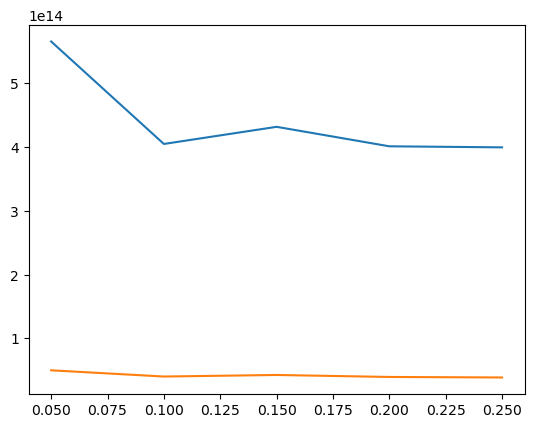

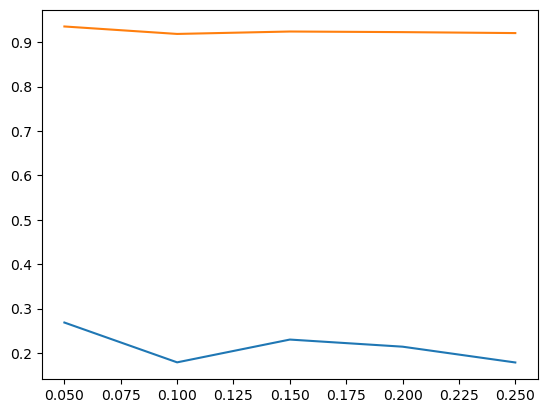

In [11]:
mse_poly=[]
r2_poly=[]
mse=[]
r2=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=i, random_state=42)
    poly=PolynomialFeatures(degree=5)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    lr=LinearRegression()
    lr.fit(x_train_poly,y_train)
    y_pred=lr.predict(x_test_poly)
    mse_poly.append( mean_squared_error(y_test,y_pred))
    r2_poly.append(r2_score(y_test,y_pred))
    
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    mse.append( mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
plt.plot(test,mse)
plt.plot(test,mse_poly)
plt.show()

plt.plot(test,r2)
plt.plot(test,r2_poly)
plt.show()